# Lab : Image Classification using Convolutional Neural Networks

At the end of this laboratory, you would get familiarized with

*   Creating deep networks using Keras
*   Steps necessary in training a neural network
*   Prediction and performance analysis using neural networks

---

# **In case you use a colaboratory environment**
By default, Colab notebooks run on CPU.
You can switch your notebook to run with GPU.

In order to obtain access to the GPU, you need to choose the tab Runtime and then select “Change runtime type” as shown in the following figure:

![Changing runtime](https://miro.medium.com/max/747/1*euE7nGZ0uJQcgvkpgvkoQg.png)

When a pop-up window appears select GPU. Ensure “Hardware accelerator” is set to GPU.

# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.

Your task is to:

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.




In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2035s 12us/step


In [8]:
y_train.shape

(50000, 1)

In [9]:
x_train.shape

(50000, 32, 32, 3)

In [11]:
y_flat = y_train.flatten()
y_flat.shape

(50000,)

In [20]:
ind_class_0 = np.where(y_flat == 0)[0]


In [27]:
random_ind = np.random.choice(ind_class_0, size = 10)

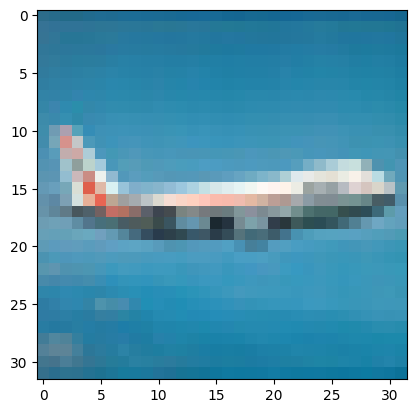

In [32]:
plt.imshow(x_train[38547])

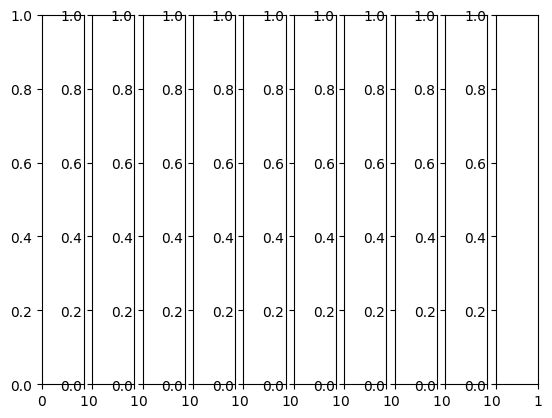

In [31]:
for i in range (10):
  plt.subplot(1, 10, i + 1)

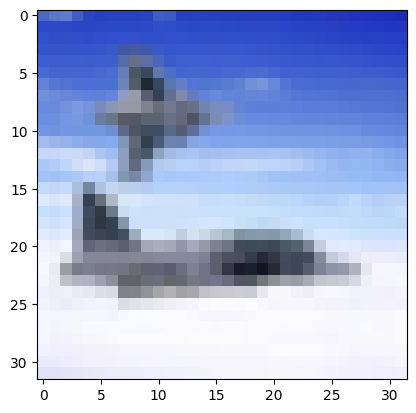

In [33]:
plt.imshow(x_train[random_ind[i]])

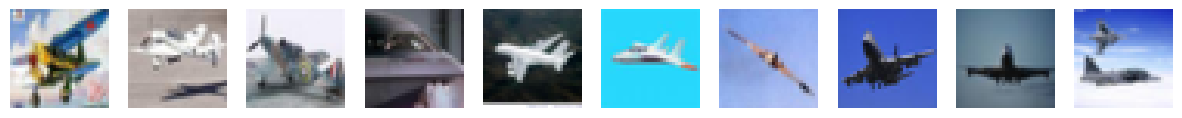

In [35]:
random_indices = np.random.choice(ind_class_0, size=10)

plt.figure(figsize=(15, 3))

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[random_ind[i]])
    plt.axis('off')

plt.show()


In [38]:
new_y_train = to_categorical(y_train, num_classes = 10)

In [39]:
new_y_test = to_categorical(y_test, num_classes = 10)

In [40]:
new_y_train.shape

(50000, 10)

In [41]:
new_x_train = x_train/255

In [42]:
new_x_test = x_test/255

In [45]:
new_x_train.max()

np.float64(1.0)

## Define the following model (same as the one in tutorial)

For the convolutional front-end, start with a single convolutional layer with a small filter size (3,3) and a modest number of filters (32) followed by a max pooling layer.

Use the input as (32,32,3).

The filter maps can then be flattened to provide features to the classifier.

Use a dense layer with 100 units before the classification layer (which is also a dense layer with softmax activation).

In [46]:
from keras.backend import clear_session
clear_session()

In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Input, Conv2D, MaxPooling2D, Flatten


In [50]:
model = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')
])



*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [55]:
model.compile(optimizer = 'sgd',loss = 'categorical_crossentropy', metrics=['accuracy'] )
history = model.fit(new_x_train, new_y_train, epochs = 50, batch_size = 512)


Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5674 - loss: 1.2356
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5712 - loss: 1.2288
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5739 - loss: 1.2187
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5751 - loss: 1.2159
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5773 - loss: 1.2097
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5810 - loss: 1.1988
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5814 - loss: 1.1976
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5878 - loss: 1.1842
Epoch 9/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5870 - loss: 1.1837
Epoch 10/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5883 - loss: 1.1829
Epoch 11/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5914 - loss: 1.1748
Epoch 12/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5922

*   Plot the cross entropy loss curve and the accuracy curve

In [56]:
history.history['loss']

[1.2356417179107666,
 1.2288390398025513,
 1.2186857461929321,
 1.2159347534179688,
 1.2097468376159668,
 1.198760747909546,
 1.1975561380386353,
 1.1842159032821655,
 1.1836820840835571,
 1.1828893423080444,
 1.1748408079147339,
 1.1667941808700562,
 1.1620315313339233,
 1.1585924625396729,
 1.1530940532684326,
 1.148229956626892,
 1.1450713872909546,
 1.138381004333496,
 1.1368645429611206,
 1.1297732591629028,
 1.1229052543640137,
 1.1223646402359009,
 1.118762493133545,
 1.1120494604110718,
 1.107366681098938,
 1.1052539348602295,
 1.1030521392822266,
 1.0956487655639648,
 1.0877248048782349,
 1.083728313446045,
 1.0835940837860107,
 1.0767066478729248,
 1.0763241052627563,
 1.0685582160949707,
 1.0646464824676514,
 1.0661647319793701,
 1.059158444404602,
 1.053307294845581,
 1.0509196519851685,
 1.0493266582489014,
 1.0456931591033936,
 1.035662055015564,
 1.0362458229064941,
 1.0304052829742432,
 1.0247622728347778,
 1.027624487876892,
 1.0208271741867065,
 1.0152842998504639,
 1

In [57]:
history.history['accuracy']

[0.5674399733543396,
 0.5712199807167053,
 0.5738800168037415,
 0.5751399993896484,
 0.5773199796676636,
 0.5810199975967407,
 0.5813800096511841,
 0.5877799987792969,
 0.5870000123977661,
 0.5883399844169617,
 0.5913599729537964,
 0.5922399759292603,
 0.5946000218391418,
 0.5968000292778015,
 0.597599983215332,
 0.5990399718284607,
 0.5997800230979919,
 0.6044600009918213,
 0.605239987373352,
 0.6068400144577026,
 0.6086599826812744,
 0.6086000204086304,
 0.6101400256156921,
 0.6139400005340576,
 0.6151599884033203,
 0.6156399846076965,
 0.6159200072288513,
 0.6187400221824646,
 0.6227999925613403,
 0.6229000091552734,
 0.623420000076294,
 0.626479983329773,
 0.6276999711990356,
 0.6302599906921387,
 0.6319800019264221,
 0.6312599778175354,
 0.632319986820221,
 0.6333799958229065,
 0.6338199973106384,
 0.6363999843597412,
 0.637719988822937,
 0.6414399743080139,
 0.6426799893379211,
 0.6428599953651428,
 0.6462399959564209,
 0.6441199779510498,
 0.6476200222969055,
 0.6492599844932556

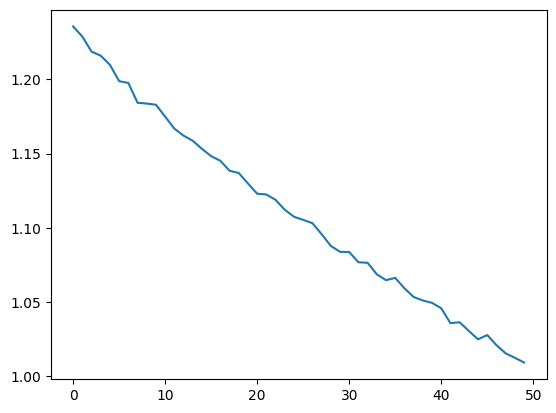

In [59]:
plt.plot(history.history['loss'])

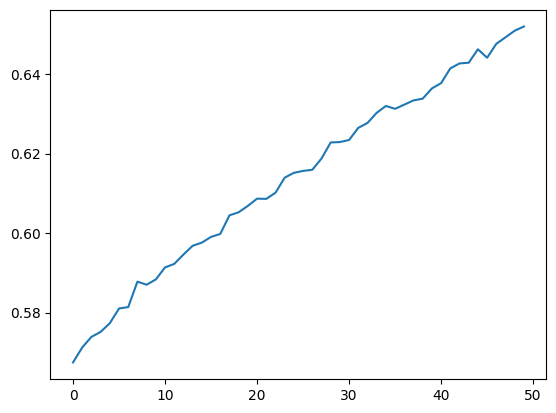

In [60]:
plt.plot(history.history['accuracy'])

## Defining Deeper Architectures: VGG Models

*   Define a deeper model architecture for CIFAR-10 dataset and train the new model for 50 epochs with a batch size of 512. We will use VGG model as the architecture.

Stack two convolutional layers with 32 filters, each of 3 x 3.

Use a max pooling layer and next flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input


In [61]:
from keras.backend import clear_session
clear_session()

In [63]:
model = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(32, kernel_size=(3, 3), activation='relu', padding = 'same'),
    Conv2D(32, kernel_size=(3, 3), activation='relu', padding = 'same'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])


*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [64]:
model.compile(optimizer = 'sgd',loss = 'categorical_crossentropy', metrics=['accuracy'] )
history_deep = model.fit(new_x_train, new_y_train, epochs = 50, batch_size = 512)


Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.1626 - loss: 2.2646
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.2566 - loss: 2.1153
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.2973 - loss: 1.9890
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3298 - loss: 1.9146
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.3526 - loss: 1.8610
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.3689 - loss: 1.8108
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3813 - loss: 1.7764
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3904 - loss: 1.7438
Epoch 9/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.4038 - loss: 1.7100
Epoch 10/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4115 - loss: 1.6796
Epoch 11/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4225 - loss: 1.6489
Epoch 12/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy:

*   Compare the performance of both the models by plotting the loss and accuracy curves of both the training steps. Does the deeper model perform better? Comment on the observation.


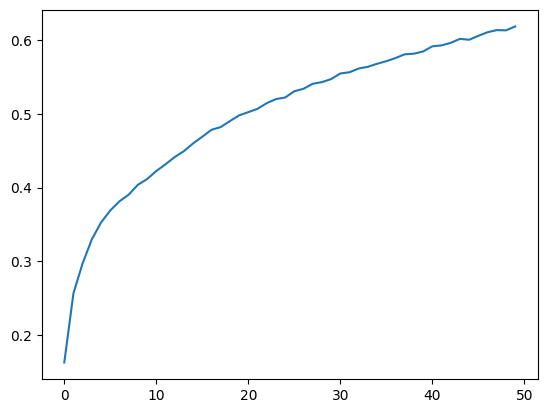

In [69]:
plt.plot(history_deep.history['accuracy'])

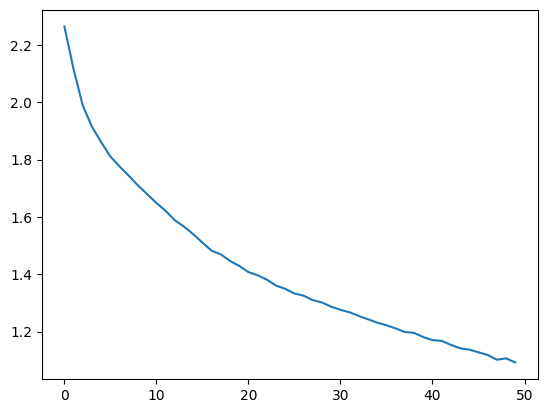

In [70]:
plt.plot(history_deep.history['loss'])

**Comment on the observation**

*(Double-click or enter to edit)*

...

*   Use predict function to predict the output for the test split
*   Plot the confusion matrix for the new model and comment on the class confusions.


In [71]:
predictions = model.predict(new_x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [72]:
predictions.shape

(10000, 10)

In [74]:
pred_class = np.argmax(predictions, axis = 1)

In [75]:
pred_class[:10]

array([3, 1, 0, 8, 4, 6, 1, 6, 2, 1])

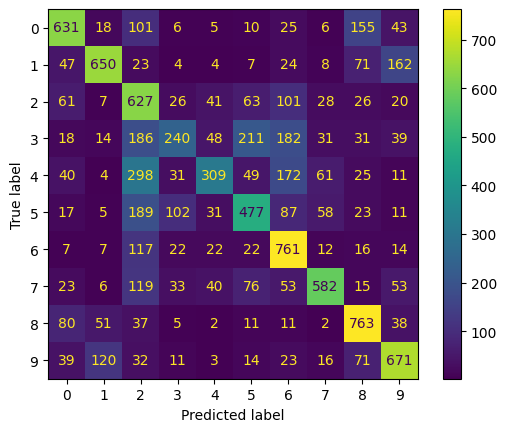

In [77]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_test_flat = y_test.flatten()
cm = confusion_matrix(y_test_flat, pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

**Comment here :**

*(Double-click or enter to edit)*

...

*    Print the test accuracy for the trained model.

In [78]:
test_loss, test_accuracy = model.evaluate(new_x_test, new_y_test, verbose=0)

print("Test accuracy:", test_accuracy)
print("Test accuracy %:", test_accuracy * 100)

Test accuracy: 0.5710999965667725
Test accuracy %: 57.109999656677246


## Define the complete VGG architecture.

Stack two convolutional layers with 64 filters, each of 3 x 3 followed by max pooling layer.

Stack two more convolutional layers with 128 filters, each of 3 x 3, followed by max pooling, followed by two more convolutional layers with 256 filters, each of 3 x 3, followed by max pooling.

Flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input

*   Change the size of input to 64 x 64.

In [80]:
from keras.backend import clear_session
clear_session()

In [81]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Resizing, Conv2D, MaxPooling2D, Flatten, Dense

model_vgg = Sequential([
    Input(shape=(32, 32, 3)),
    Resizing(64, 64),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 10 epochs with a batch size of 512.
*   Predict the output for the test split and plot the confusion matrix for the new model and comment on the class confusions.

In [83]:
model_vgg.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_vgg = model_vgg.fit(
    new_x_train,
    new_y_train,
    epochs=10,
    batch_size=512
)

Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 65s 634ms/step - accuracy: 0.1469 - loss: 2.2951
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 36s 364ms/step - accuracy: 0.1827 - loss: 2.2499
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 36s 364ms/step - accuracy: 0.2181 - loss: 2.1416
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 36s 363ms/step - accuracy: 0.2661 - loss: 2.0717
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 36s 364ms/step - accuracy: 0.3104 - loss: 1.9748
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 36s 364ms/step - accuracy: 0.3360 - loss: 1.8890
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 36s 364ms/step - accuracy: 0.3670 - loss: 1.8021
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 36s 363ms/step - accuracy: 0.3907 - loss: 1.7278
Epoch 9/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 36s 364ms/step - accuracy: 0.4169 - loss: 1.6641
Epoch 10/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 36s 364ms/step - accuracy: 0.4342 - loss: 1.6111


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step


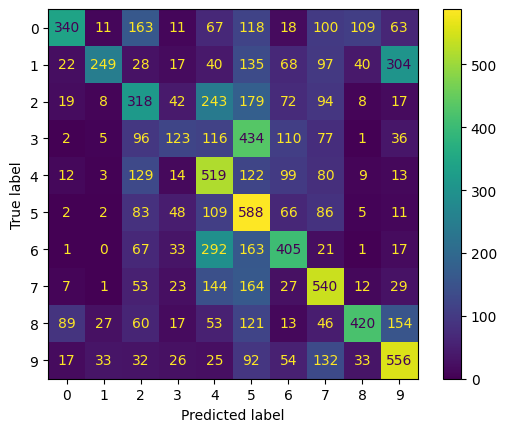

In [84]:
predictions_vgg = model_vgg.predict(new_x_test)
pred_class_vgg = np.argmax(predictions_vgg, axis=1)

y_test_flat = y_test.flatten()

cm_vgg = confusion_matrix(y_test_flat, pred_class_vgg)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_vgg)
disp.plot()
plt.show()

# Understanding deep networks

*   What is the use of activation functions in network? Why is it needed?
*   We have used softmax activation function in the exercise. There are other activation functions available too. What is the difference between sigmoid activation and softmax activation?
*   What is the difference between categorical crossentropy and binary crossentropy loss?

**Write the answers below :**

1 - Use of activation functions:

activation functions help the network learn complex patterns and decide what information should pass to the next layer

2 - Key Differences between sigmoid and softmax:

sigmoid gives each output a value between 0 and 1 independently, while softmax turns all outputs into probabilities that add up to 1

3 - Key Differences between categorical crossentropy and binary crossentropy loss:

binary crossentropy is used for two classes, while categorical crossentropy is used for multiple classes
_
